In [130]:
import torch

checkpoint_path = 'checkpoint/2025年11月17日 > 23:43/best_model.pth'
checkpoint = torch.load(checkpoint_path)

In [131]:
checkpoint.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_accuracy', 'val_loss', 'global_step'])

In [132]:
from model.FullModel import RINEPlusSSCA

model = RINEPlusSSCA()
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
from tools.utils import print_model_summary
from tools.heatmap import AttentionVisualizer
# print_model_summary(model)


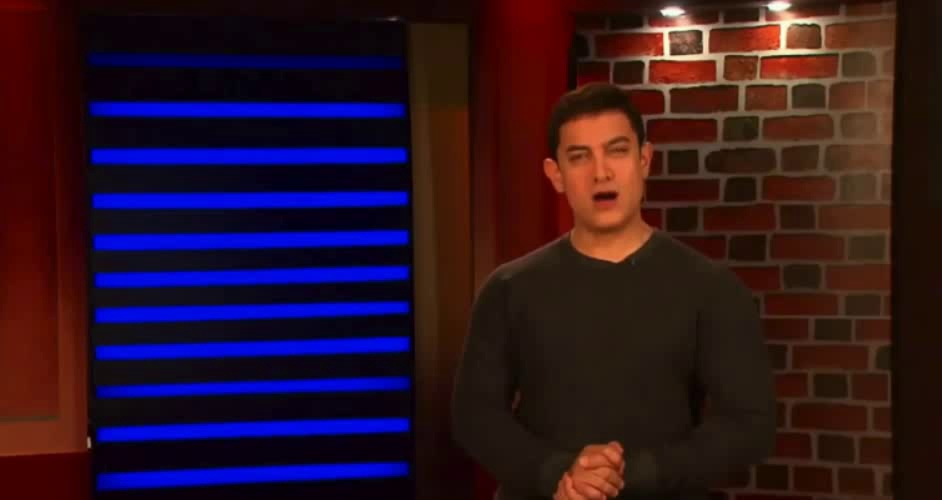

In [133]:
from tools.image_preprocess import transforms_val
from PIL import Image


img_path = '/home/liangshuqiao/hong/deepfake/rine_opt/dataset/Celeb-DF/id0_0000/id0_0000_frame000000.jpg'
img  = Image.open(img_path).convert('RGB')
img

In [134]:
img_t = transforms_val(img)


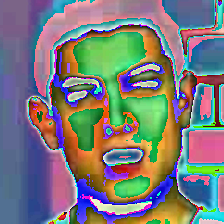

In [135]:
from torchvision import transforms
transforms.ToPILImage()(img_t)

In [136]:
img_t = img_t.unsqueeze(0)

In [137]:
import pandas as pd
with open('dataset/Celeb-DF/labels.csv','r',encoding='utf-8') as f:
    label_file = pd.read_csv(f)
label_file

,path,label,video,frame
0,/home/liangshuqiao/hong/deepfake/rine_opt/data...,0,id0_0000,0
1,/home/liangshuqiao/hong/deepfake/rine_opt/data...,0,id0_0000,10
2,/home/liangshuqiao/hong/deepfake/rine_opt/data...,0,id0_0000,20
3,/home/liangshuqiao/hong/deepfake/rine_opt/data...,0,id0_0000,30
4,/home/liangshuqiao/hong/deepfake/rine_opt/data...,0,id0_0000,40
...,...,...,...,...
60720,dataset/Celeb-DF/00249/00249_frame000495.jpg,0,00249,495
60721,dataset/Celeb-DF/00249/00249_frame000500.jpg,0,00249,500
60722,dataset/Celeb-DF/00249/00249_frame000505.jpg,0,00249,505
60723,dataset/Celeb-DF/00249/00249_frame000510.jpg,0,00249,510


In [138]:
label = label_file[label_file['path'] == img_path]['label']


In [139]:
with torch.no_grad():
    output = model(img_t)


In [140]:
import torch.nn.functional as F

# 推理时获得概率
probabilities = F.sigmoid(output[0])
result = pd.DataFrame(
    {
        'predict': [float(probabilities)],
        'real': [int(label)]
    },
    index=None
)

/tmp/ipykernel_3772721/2825584275.py:8: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  'real': [int(label)]


In [141]:
result

,predict,real
0,0.189069,0


In [142]:
from collections import Counter
Counter(label_file['label'])

Counter({1: 31632, 0: 29093})

In [143]:
visual = AttentionVisualizer(model)
layers = ['', 'clip', 'clip.vision_model', 'clip.vision_model.embeddings', 'clip.vision_model.embeddings.patch_embedding', 'clip.vision_model.embeddings.position_embedding', 'clip.vision_model.pre_layrnorm', 'clip.vision_model.encoder', 'clip.vision_model.encoder.layers', 'clip.vision_model.encoder.layers.0']
for layer in layers:
    visual.visualize_spatial_attention(img_t,show_input=True,target_layer=layer)

AttributeError: 'tuple' object has no attribute 'detach'